In [1]:
import joblib

model = joblib.load("sales_forecast_model.pkl")
features = joblib.load("feature_names.pkl")

In [2]:
import pandas as pd

old_df=pd.read_csv("Processed_Sales_data.csv")
last_date=old_df['Order Date'].max()
print(last_date)
last_date=pd.to_datetime(last_date)
next_date = last_date + pd.Timedelta(days=1)
print(next_date)
print(str(next_date)[:10])
start_date=pd.to_datetime(str(next_date)[:10])

2017-12-30
2017-12-31 00:00:00
2017-12-31


In [3]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

sales_history = old_df['Sales'].tail(30).tolist()
str_season=list(old_df['Season'])
old_df['Season']=le.fit_transform(old_df['Season'])
int_season=list(old_df['Season'])

last_row = old_df.iloc[-1].copy()
#print(str_season,int_season)
str_season = ['Winter', 'Summer', 'Rainy', 'Spring']
int_season = [3, 2, 0, 1]

season_map_int_to_str = dict(zip(int_season, str_season))
season_map_str_to_int = dict(zip(str_season, int_season))

#future_df['Season'] = future_df['Season'].map(season_map)

In [4]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Spring'
    else:
        return 'Rainy'

In [5]:
import numpy as np
def predict(days):
    future_predictions = []
    for i in range(days):
    
        next_date = pd.to_datetime(last_row['Order Date']) + pd.Timedelta(days=1)
    
        row = {}
    
        row['Year'] = next_date.year
        row['Month'] = next_date.month
        row['Day'] = next_date.day
        row['Day of week'] = next_date.dayofweek
        row['Quarter'] = next_date.quarter
    
        row['Time_Index'] = last_row['Time_Index'] + 1
    
        row['Lag_1'] = sales_history[-1]
        row['Lag_7'] = sales_history[-7]
        row['Lag_14'] = sales_history[-14]
        row['Lag_30'] = sales_history[-30]
    
        row['Rolling_14'] = np.mean(sales_history[-14:])
        row['Avg of week'] = np.mean(sales_history[-7:])
    
        row['Lag_7_rolling_mean'] = np.mean(sales_history[-7:])
        row['Lag_14_rolling_std'] = np.std(sales_history[-14:])
    
        row['Quantity'] = last_row['Quantity']   # assumption
        row['Qty_x_AvgWeek'] = row['Quantity'] * row['Avg of week']
    
        row['month_sin'] = np.sin(2*np.pi*row['Month']/12)
        row['month_cos'] = np.cos(2*np.pi*row['Month']/12)
    
        row['dow_sin'] = np.sin(2*np.pi*row['Day of week']/7)
        row['dow_cos'] = np.cos(2*np.pi*row['Day of week']/7)

        #print(season_map_str_to_int[get_season(row['Month'])])
        row['Season'] = season_map_str_to_int[get_season(row['Month'])]
        row['expanding_mean'] = np.mean(sales_history)
    
        X_future = pd.DataFrame([row])
    
        pred = model.predict(X_future)[0]
        
        row['Date'] = next_date
        row['Predicted Sales'] = pred
    
        future_predictions.append(row)
    
        sales_history.append(pred)
    
        last_row['Order Date'] = next_date
        last_row['Time_Index'] = row['Time_Index']
    return future_predictions

In [6]:
future_predictions = predict(7)
future_df = pd.DataFrame(future_predictions)
print(le.classes_)
future_df['Season'] = le.inverse_transform(future_df['Season'])
future_df.to_csv(
    "Future_Sales_Forecast.csv",
    index=False
)
future_df

['Rainy' 'Spring' 'Summer' 'Winter']


,Year,Month,Day,Day of week,Quarter,Time_Index,Lag_1,Lag_7,Lag_14,Lag_30,...,Quantity,Qty_x_AvgWeek,month_sin,month_cos,dow_sin,dow_cos,Season,expanding_mean,Date,Predicted Sales
0,2017,12,31,6,4,1237,713.790000,6233.0540,2027.758,6645.282,...,23,49978.624771,-2.449294e-16,1.000000,-0.781831,0.623490,Winter,3015.820027,2017-12-31,2156.987294
1,2018,1,1,0,1,1238,2156.987294,2698.9270,3645.911,5331.178,...,23,36585.834165,5.000000e-01,0.866025,0.000000,1.000000,Winter,2988.115745,2018-01-01,2388.403774
2,2018,1,2,1,1,1239,2388.403774,814.5940,1895.926,9951.182,...,23,35565.543564,5.000000e-01,0.866025,0.781831,0.623490,Winter,2969.374746,2018-01-02,2442.529844
3,2018,1,3,2,1,1240,2442.529844,177.6360,377.736,1403.842,...,23,40914.475624,5.000000e-01,0.866025,0.974928,-0.222521,Winter,2953.409749,2018-01-03,2493.494474
4,2018,1,4,3,1,1241,2493.494474,1657.3508,2140.940,2639.638,...,23,48523.724894,5.000000e-01,0.866025,0.433884,-0.900969,Winter,2939.882829,2018-01-04,2449.785024
5,2018,1,5,4,1,1242,2449.785024,2915.5340,7442.021,1453.136,...,23,51127.437345,5.000000e-01,0.866025,-0.433884,-0.900969,Winter,2925.880035,2018-01-05,2351.195828
6,2018,1,6,5,1,1243,2351.195828,713.7900,1926.776,10.680,...,23,49273.183350,5.000000e-01,0.866025,-0.974928,-0.222521,Winter,2909.916584,2018-01-06,2383.975080


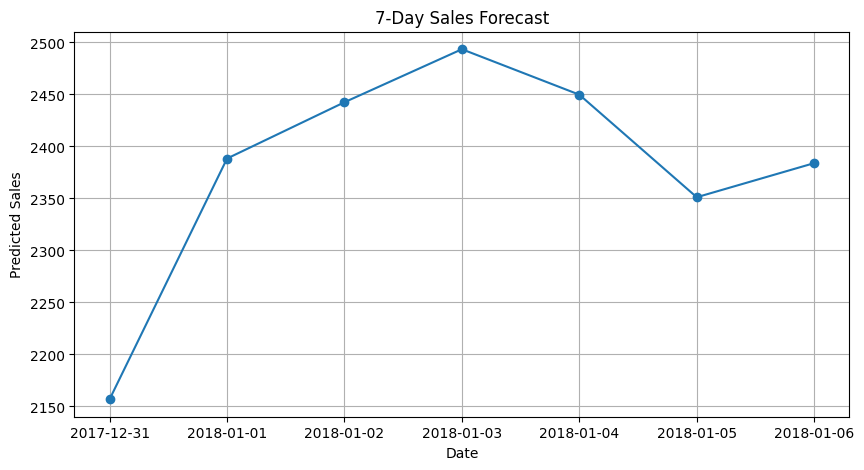

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
    future_df['Date'],
    future_df['Predicted Sales'],
    marker='o'
)

plt.title("7-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.savefig("sales_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
str_season = ['Winter', 'Summer', 'Rainy', 'Spring']
int_season = [3, 2, 0, 1]

season_map_int_to_str = dict(zip(int_season, str_season))
future_df['Season'] = future_df['Season'].map(season_map_int_to_str)

In [8]:
business_forecast = future_df[
    [
        'Date',
        'Predicted Sales',
        'Avg of week',
        'Lag_1',
        'Quantity'
    ]
]

business_forecast

,Date,Predicted Sales,Avg of week,Lag_1,Quantity
0,2017-12-31,2156.987294,2172.983686,713.790000,23
1,2018-01-01,2388.403774,1590.688442,2156.987294,23
2,2018-01-02,2442.529844,1546.327981,2388.403774,23
3,2018-01-03,2493.494474,1778.890245,2442.529844,23
4,2018-01-04,2449.785024,2109.727169,2493.494474,23
5,2018-01-05,2351.195828,2222.932058,2449.785024,23
6,2018-01-06,2383.975080,2142.312320,2351.195828,23


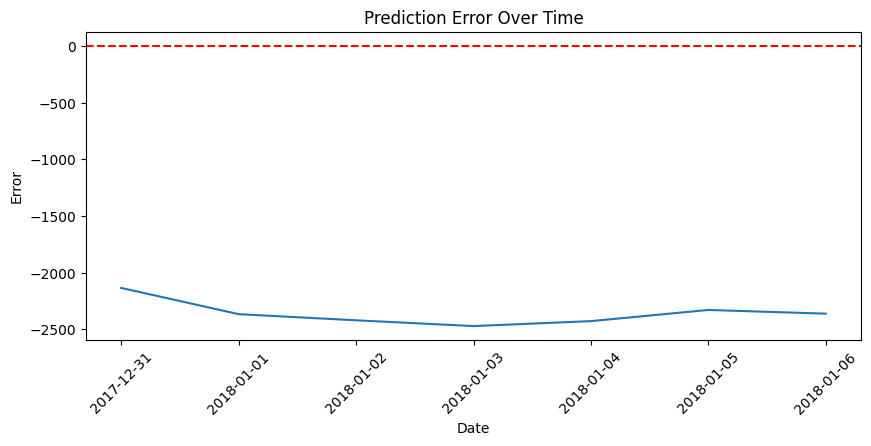

In [11]:
future_df['error'] = future_df['Quantity'] - future_df['Predicted Sales']

plt.figure(figsize=(10,4))
plt.plot(future_df['Date'], future_df['error'])
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Error Over Time")
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Error')
#plt.legend()
plt.savefig("sales_forecast_residual_7_days.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
future_pred2=predict(100)
future_df2 = pd.DataFrame(future_pred2)
future_df2['Season'] = future_df2['Season'].map(season_map_int_to_str)
print(set(future_df2['Season']))
future_df2['error'] = future_df2['Quantity'] - future_df2['Predicted Sales']

{'Spring', 'Summer'}


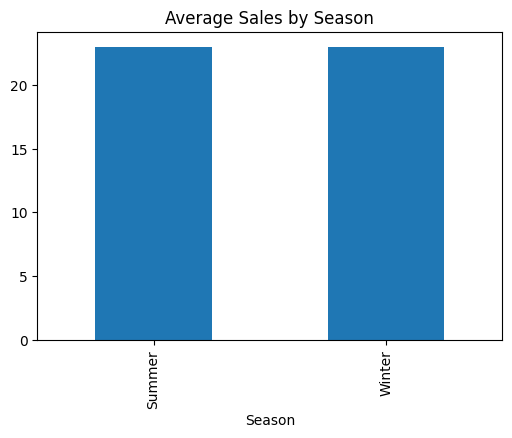

In [16]:
future_df2.groupby('Season')['Quantity'].mean().plot(kind='bar', figsize=(6,4))
plt.title("Average Sales by Season")
plt.savefig("Average Sales by Season", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
future_df2.to_csv("future_sales_100.csv",index=False)
future_df2

,Year,Month,Day,Day of week,Quarter,Time_Index,Lag_1,Lag_7,Lag_14,Lag_30,...,Qty_x_AvgWeek,month_sin,month_cos,dow_sin,dow_cos,Season,expanding_mean,Date,Predicted Sales,error
0,2018,4,24,1,2,1351,2352.758840,2381.958952,2392.775500,2287.465371,...,53779.005725,0.866025,-0.500000,0.781831,0.623490,Summer,2479.634350,2018-04-24,2382.966190,-2359.966190
1,2018,4,25,2,2,1352,2382.966190,2371.125330,2380.358298,2355.731253,...,53782.315221,0.866025,-0.500000,0.974928,-0.222521,Summer,2478.967673,2018-04-25,2381.894134,-2358.894134
2,2018,4,26,3,2,1353,2381.894134,2379.627982,2368.399018,2377.268873,...,53817.698434,0.866025,-0.500000,0.433884,-0.900969,Summer,2478.302786,2018-04-26,2368.340850,-2345.340850
3,2018,4,27,4,2,1354,2368.340850,2294.493440,2302.557629,2373.113333,...,53780.612146,0.866025,-0.500000,-0.433884,-0.900969,Summer,2477.554745,2018-04-27,2294.611270,-2271.611270
4,2018,4,28,5,2,1355,2294.611270,2294.493440,2302.557629,2359.560050,...,53780.999302,0.866025,-0.500000,-0.974928,-0.222521,Summer,2476.318641,2018-04-28,2293.618475,-2270.618475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2018,7,28,5,3,1446,2293.716798,2296.131771,2302.929558,2374.722270,...,53821.670373,-0.500000,-0.866025,-0.974928,-0.222521,Spring,2424.438752,2018-07-28,2292.306229,-2269.306229
96,2018,7,29,6,3,1447,2292.306229,2294.703828,2295.514534,2293.042441,...,53809.100736,-0.500000,-0.866025,-0.781831,0.623490,Spring,2423.888199,2018-07-29,2292.306229,-2269.306229
97,2018,7,30,0,3,1448,2292.306229,2354.397171,2355.207876,2293.042441,...,53801.222910,-0.500000,-0.866025,0.000000,1.000000,Spring,2423.342216,2018-07-30,2351.999571,-2328.999571
98,2018,7,31,1,3,1449,2351.999571,2381.653944,2380.646706,2301.420365,...,53793.345084,-0.500000,-0.866025,0.781831,0.623490,Spring,2423.047412,2018-07-31,2376.317028,-2353.317028


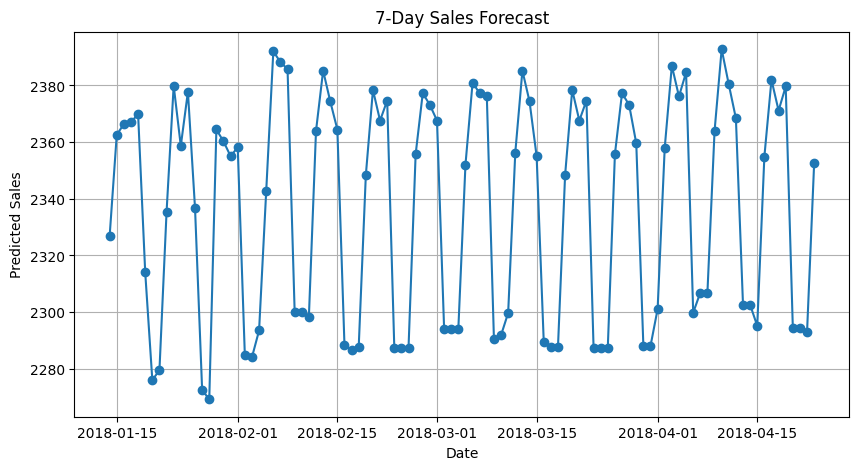

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    future_df2['Date'],
    future_df2['Predicted Sales'],
    marker='o'
)

plt.title("7-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
#plt.savefig("sales_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

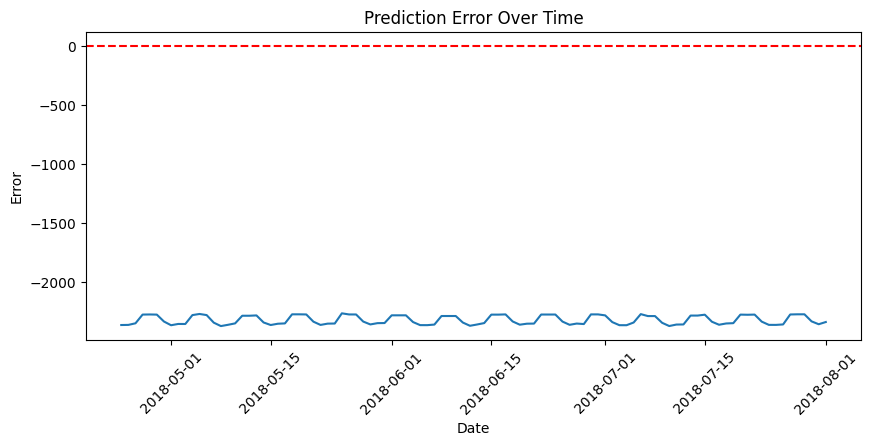

In [24]:
plt.figure(figsize=(10,4))
plt.plot(future_df2['Date'], future_df2['error'])
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Error Over Time")
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Error')
#plt.legend()
plt.savefig("sales_forecast_residual.png", dpi=300, bbox_inches='tight')
plt.show()